In [1]:
import json
from collections import Counter

datapaths = ["referencegame_data_DS_v0.json", "referencegame_data_DS_v1.json", "referencegame_data_DS_v2.json",
            "referencegame_data_llms_DS_v0.json", "referencegame_data_llms_DS_v1.json", "referencegame_data_llms_DS_v2.json"] 

meta_data = {
    "v0": dict(),
    "v1": dict(),
    "v2": dict(),
    "llms_v0": dict(),
    "llms_v1": dict(),
    "llms_v2": dict()
}

for datapath in datapaths:
    if "llms" in datapath:
        if "v0" in datapath:
            version = "llms_v0"
        elif "v1" in datapath:
            version = "llms_v1"
        else:
            version = "llms_v2"
    else:
        if "v0" in datapath:
            version = "v0"
        elif "v1" in datapath:
            version = "v1"
        else:
            version = "v2"
        
    with open(datapath, 'r') as f:
        rows = json.load(f)
              
    total_interactions = len(rows)
    ds_interactions = [row for row in rows if "DS" in row["source"]]
    
    meta_data[version]["total_interactions"] = total_interactions
    meta_data[version]["num_of_DS_interactions"] = len(ds_interactions)
    meta_data[version]["num_of_not_DS_interactions"] = total_interactions - len(ds_interactions)


    #####

    # Extract the roles from each dictionary
    roles_DS = [row["role"] for row in rows if "DS" in row["source"]]
    roles_not_DS = [row["role"] for row in rows if "DS" not in row["source"]]

    # Count them
    role_count_DS = dict(Counter(roles_DS))
    role_count_not_DS = dict(Counter(roles_not_DS))
    
    meta_data[version]["role_distribution_DS"] = dict(role_count_DS)
    meta_data[version]["role_distribution_not_DS"] = dict(role_count_not_DS)

    ######

    # (role, status) combinations
    role_status_count = Counter((row["role"], row["status"]) for row in rows)

    # (role, reward) combinations
    role_reward_count = Counter((row["role"], row["reward"]) for row in rows)

    meta_data[version]["role_status_distribution"] = dict(role_status_count)
    meta_data[version]["role_reward_distribution"] = dict(role_reward_count)



print(meta_data)

{'v0': {'total_interactions': 937, 'num_of_DS_interactions': 230, 'num_of_not_DS_interactions': 707, 'role_distribution_DS': {'comp': 108, 'gen': 122}, 'role_distribution_not_DS': {'gen': 288, 'comp': 419}, 'role_status_distribution': {('gen', 'finished'): 374, ('gen', 'aborted'): 36, ('comp', 'finished'): 527}, 'role_reward_distribution': {('gen', 1): 230, ('gen', -1): 180, ('comp', -1): 297, ('comp', 1): 230}}, 'v1': {'total_interactions': 1374, 'num_of_DS_interactions': 422, 'num_of_not_DS_interactions': 952, 'role_distribution_DS': {'gen': 142, 'comp': 280}, 'role_distribution_not_DS': {'comp': 427, 'gen': 525}, 'role_status_distribution': {('comp', 'finished'): 707, ('gen', 'finished'): 657, ('gen', 'aborted'): 10}, 'role_reward_distribution': {('comp', -1): 285, ('comp', 1): 422, ('gen', 1): 422, ('gen', -1): 245}}, 'v2': {'total_interactions': 677, 'num_of_DS_interactions': 174, 'num_of_not_DS_interactions': 503, 'role_distribution_DS': {'gen': 84, 'comp': 90}, 'role_distributio

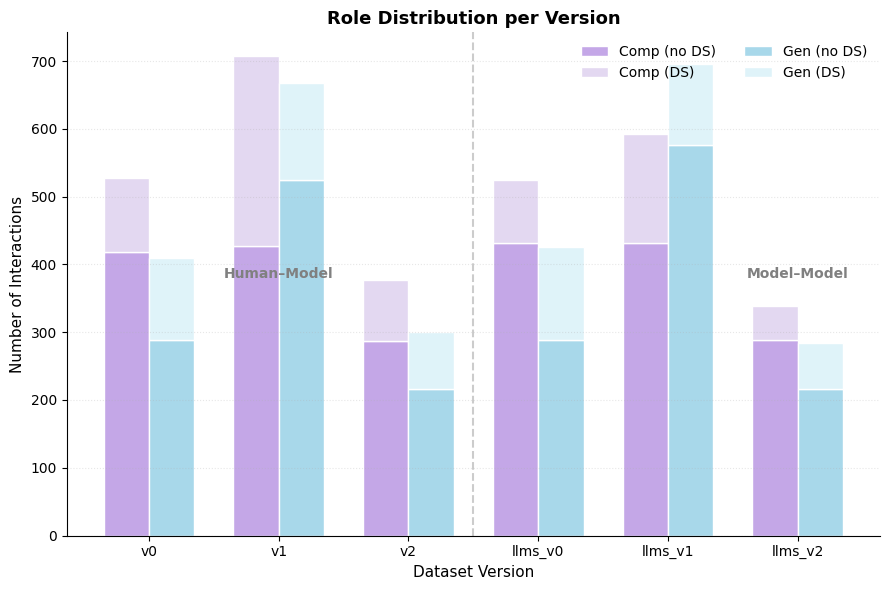

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Versions
versions = [v for v in meta_data.keys() if meta_data[v]]

comp_not_DS = [meta_data[v]["role_distribution_not_DS"].get("comp", 0) for v in versions]
gen_not_DS  = [meta_data[v]["role_distribution_not_DS"].get("gen", 0) for v in versions]
comp_DS     = [meta_data[v]["role_distribution_DS"].get("comp", 0) for v in versions]
gen_DS      = [meta_data[v]["role_distribution_DS"].get("gen", 0) for v in versions]

x = np.arange(len(versions))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

# color palette
colors = {
    "comp_no": "#c4a7e7",  # soft purple
    "comp_ds": "#e3d8f1",  # lighter lilac
    "gen_no": "#a8d8ea",   # soft blue
    "gen_ds": "#dff3f9"    # light aqua
}

# --- Bars ---
bars_comp_base = ax.bar(x - bar_width/2, comp_not_DS, width=bar_width,
                        color=colors["comp_no"], label='Comp (no DS)', edgecolor='white')
bars_comp_ds   = ax.bar(x - bar_width/2, comp_DS, width=bar_width,
                        bottom=comp_not_DS, color=colors["comp_ds"], label='Comp (DS)', edgecolor='white')

bars_gen_base = ax.bar(x + bar_width/2, gen_not_DS, width=bar_width,
                       color=colors["gen_no"], label='Gen (no DS)', edgecolor='white')
bars_gen_ds   = ax.bar(x + bar_width/2, gen_DS, width=bar_width,
                       bottom=gen_not_DS, color=colors["gen_ds"], label='Gen (DS)', edgecolor='white')

# labels and style
ax.set_xlabel('Dataset Version', fontsize=11)
ax.set_ylabel('Number of Interactions', fontsize=11)
ax.set_title('Role Distribution per Version', fontsize=13, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions, rotation=0)

# divider and section labels
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.4)
ax.text(1, max(comp_DS)+100, 'Human–Model', ha='center', fontsize=10, fontweight='bold', color='gray')
ax.text(5, max(comp_DS)+100, 'Model–Model', ha='center', fontsize=10, fontweight='bold', color='gray')

# legend etc.
ax.legend(frameon=False, ncol=2, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

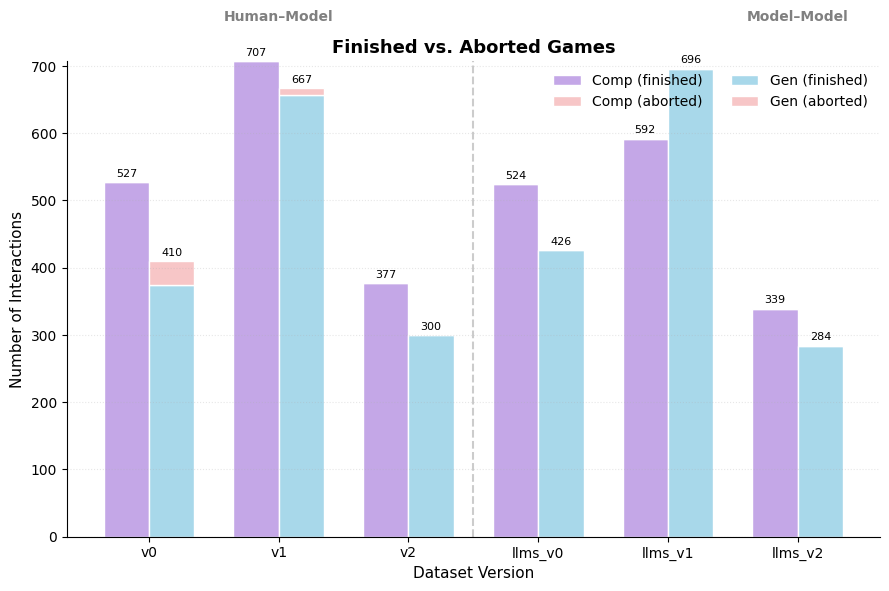

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# data extraction
finished_comp, aborted_comp, finished_gen, aborted_gen = [], [], [], []

for v in versions:
    status_dist = meta_data[v].get("role_status_distribution", {})
    finished_comp.append(status_dist.get(("comp", "finished"), 0))
    aborted_comp.append(status_dist.get(("comp", "aborted"), 0))
    finished_gen.append(status_dist.get(("gen", "finished"), 0))
    aborted_gen.append(status_dist.get(("gen", "aborted"), 0))

x = np.arange(len(versions))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    "comp_finished": "#c4a7e7",  # pastel violet
    "comp_aborted":  "#f7c6c7",  # light rose
    "gen_finished":  "#a8d8ea",  # pastel blue
    "gen_aborted":   "#f7c6c7"   # same light rose for consistency
}

# COMP bars
bars_comp_finished = ax.bar(
    x - bar_width/2, finished_comp, width=bar_width,
    color=colors["comp_finished"], edgecolor='white', label='Comp (finished)'
)
bars_comp_aborted = ax.bar(
    x - bar_width/2, aborted_comp, width=bar_width,
    bottom=finished_comp, color=colors["comp_aborted"],
    edgecolor='white', label='Comp (aborted)'
)

# GEN bars
bars_gen_finished = ax.bar(
    x + bar_width/2, finished_gen, width=bar_width,
    color=colors["gen_finished"], edgecolor='white', label='Gen (finished)'
)
bars_gen_aborted = ax.bar(
    x + bar_width/2, aborted_gen, width=bar_width,
    bottom=finished_gen, color=colors["gen_aborted"],
    edgecolor='white', label='Gen (aborted)'
)

# labels and style
ax.set_xlabel('Dataset Version', fontsize=11)
ax.set_ylabel('Number of Interactions', fontsize=11)
ax.set_title('Finished vs. Aborted Games', fontsize=13, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions, rotation=0)

# vertical divider
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.4)
ax.text(1, max(finished_comp) + 60, 'Human–Model', ha='center', fontsize=10, fontweight='bold', color='gray')
ax.text(5, max(finished_comp) + 60, 'Model–Model', ha='center', fontsize=10, fontweight='bold', color='gray')

# legend & aesthetics
ax.legend(frameon=False, ncol=2, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.3)

# add numeric labels for totals
def add_labels(bars, bottoms=None):
    for i, bar in enumerate(bars):
        height = bar.get_height()
        total = height + (bottoms[i] if bottoms is not None else 0)
        if total > 0:
            ax.text(bar.get_x() + bar.get_width()/2, total + 5,
                    f'{int(total)}', ha='center', va='bottom', fontsize=8)

add_labels(bars_comp_aborted, finished_comp)
add_labels(bars_gen_aborted, finished_gen)

plt.tight_layout()
plt.show()

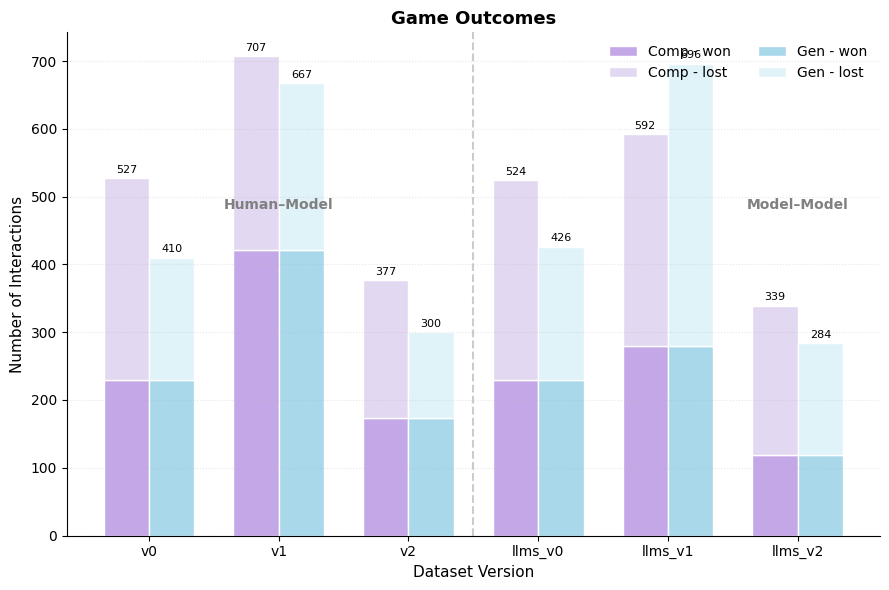

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# data extraction
reward_pos_comp, reward_neg_comp, reward_pos_gen, reward_neg_gen = [], [], [], []

for v in versions:
    reward_dist = meta_data[v].get("role_reward_distribution", {})
    reward_pos_comp.append(reward_dist.get(("comp", 1), 0))
    reward_neg_comp.append(reward_dist.get(("comp", -1), 0))
    reward_pos_gen.append(reward_dist.get(("gen", 1), 0))
    reward_neg_gen.append(reward_dist.get(("gen", -1), 0))

x = np.arange(len(versions))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    "comp_success": "#c4a7e7",  # pastel green
    "comp_failure": "#e3d8f1",  # pastel red
    "gen_success":  "#a8d8ea",  # pastel blue
    "gen_failure":  "#dff3f9"   # same red tone for consistency
}

# COMP bars
bars_comp_success = ax.bar(
    x - bar_width/2, reward_pos_comp, width=bar_width,
    color=colors["comp_success"], edgecolor='white', label='Comp - won'
)
bars_comp_fail = ax.bar(
    x - bar_width/2, reward_neg_comp, width=bar_width,
    bottom=reward_pos_comp, color=colors["comp_failure"],
    edgecolor='white', label='Comp - lost'
)

# GEN bars
bars_gen_success = ax.bar(
    x + bar_width/2, reward_pos_gen, width=bar_width,
    color=colors["gen_success"], edgecolor='white', label='Gen - won'
)
bars_gen_fail = ax.bar(
    x + bar_width/2, reward_neg_gen, width=bar_width,
    bottom=reward_pos_gen, color=colors["gen_failure"],
    edgecolor='white', label='Gen - lost'
)

# labels and styling
ax.set_xlabel('Dataset Version', fontsize=11)
ax.set_ylabel('Number of Interactions', fontsize=11)
ax.set_title('Game Outcomes', fontsize=13, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions)

# divider
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.4)
ax.text(1, max(reward_pos_comp)+60, 'Human–Model', ha='center', fontsize=10, fontweight='bold', color='gray')
ax.text(5, max(reward_pos_comp)+60, 'Model–Model', ha='center', fontsize=10, fontweight='bold', color='gray')

ax.legend(frameon=False, ncol=2, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.3)

# numeric labels
def add_labels(bars, bottoms=None):
    for i, bar in enumerate(bars):
        height = bar.get_height()
        total = height + (bottoms[i] if bottoms is not None else 0)
        if total > 0:
            ax.text(bar.get_x() + bar.get_width()/2, total + 5,
                    f'{int(total)}', ha='center', va='bottom', fontsize=8)

add_labels(bars_comp_fail, reward_pos_comp)
add_labels(bars_gen_fail, reward_pos_gen)

plt.tight_layout()
plt.show()